# Limpieza base Saber 11 — Proyecto 2

Este notebook construye un **dataset limpio base** para el Proyecto 2.  
La idea es dejar una limpieza común y confiable para el grupo, sin hacer todavía el modelamiento específico de cada pregunta.

## Enfoque de esta limpieza

Esta limpieza busca:

1. Definir y justificar una ventana temporal razonable.
2. Estandarizar nombres de columnas y categorías.
3. Convertir tipos de datos correctamente.
4. Detectar duplicados, valores faltantes e inconsistencias.
5. Conservar información útil para que cada integrante haga su propio análisis/modelo.
6. Evitar decisiones prematuras como crear targets, escalar variables o eliminar variables útiles.

## Importante

Este notebook **no** debe hacer todavía:

- Creación definitiva de targets de regresión/clasificación.
- Escalamiento de variables.
- Balanceo de clases.
- Selección final de variables por modelo.
- Imputaciones muy específicas.

Eso lo debe hacer cada integrante en su notebook de modelamiento según su pregunta de negocio.

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import unicodedata
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 2. Carga de datos

Ajusten la ruta según el nombre real del archivo.  
Si el archivo es muy pesado, también pueden cargar una muestra inicialmente para revisar estructura.

In [2]:
# Ruta sugerida. Cambiar por la ruta real del archivo original.
RUTA_DATOS = Path("/Users/anamariasanchezmejia/Downloads/Bogota_historico_saber_11_20260522.csv")

# Si el archivo usa otro separador o encoding, ajustar sep/encoding.
df_raw = pd.read_csv(RUTA_DATOS, dtype=str, low_memory=False)

print("Dimensiones originales:", df_raw.shape)
df_raw.head()

Dimensiones originales: (1131725, 51)


,PERIODO,ESTU_TIPODOCUMENTO,ESTU_CONSECUTIVO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CALENDARIO,COLE_CARACTER,COLE_COD_DANE_ESTABLECIMIENTO,COLE_COD_DANE_SEDE,COLE_COD_DEPTO_UBICACION,COLE_COD_MCPIO_UBICACION,COLE_CODIGO_ICFES,COLE_DEPTO_UBICACION,COLE_GENERO,COLE_JORNADA,COLE_MCPIO_UBICACION,COLE_NATURALEZA,COLE_NOMBRE_ESTABLECIMIENTO,COLE_NOMBRE_SEDE,COLE_SEDE_PRINCIPAL,ESTU_COD_DEPTO_PRESENTACION,ESTU_COD_MCPIO_PRESENTACION,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,ESTU_DEPTO_PRESENTACION,ESTU_DEPTO_RESIDE,ESTU_ESTADOINVESTIGACION,ESTU_ESTUDIANTE,ESTU_FECHANACIMIENTO,ESTU_GENERO,ESTU_MCPIO_PRESENTACION,ESTU_MCPIO_RESIDE,ESTU_NACIONALIDAD,ESTU_PAIS_RESIDE,ESTU_PRIVADO_LIBERTAD,FAMI_CUARTOSHOGAR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENEAUTOMOVIL,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
0,20224,CC,SB11202240575814,URBANO,N,OTRO,ACADÉMICO,311001105863,311001105863,11,11001,088617,BOGOTÁ,MIXTO,MAÑANA,BOGOTÁ D.C.,NO OFICIAL,CENTRO JOHANN KEPLER,CENTRO JOHANN KEPLER,S,11,11001,11,11001,BOGOTÁ,BOGOTÁ,PUBLICAR,ESTUDIANTE,03/08/2003,M,BOGOTÁ D.C.,BOGOTÁ D.C.,COLOMBIA,COLOMBIA,N,Uno,Primaria completa,Primaria completa,Estrato 3,1 a 2,Si,No,No,No,A-,38,42,29,36,39,183
1,20224,TI,SB11202240134757,URBANO,N,A,ACADÉMICO,211102000995,211102000995,11,11001,185884,BOGOTÁ,MIXTO,TARDE,BOGOTÁ D.C.,OFICIAL,COLEGIO BOSANOVA (IED),CENT EDUC DIST BOSANOVA,S,11,11001,11,11001,BOGOTÁ,BOGOTÁ,PUBLICAR,ESTUDIANTE,02/11/2004,M,BOGOTÁ D.C.,BOGOTÁ D.C.,COLOMBIA,COLOMBIA,N,Tres,Primaria completa,No Aplica,Estrato 3,1 a 2,No,Si,Si,Si,A-,42,51,37,56,41,230
2,20224,TI,SB11202240029452,URBANO,N,A,ACADÉMICO,311001075034,311001075034,11,11001,098335,BOGOTÁ,MIXTO,TARDE,BOGOTÁ D.C.,OFICIAL,COLEGIO CANADA (IED),CENT EDUC DIST CANADA,S,11,11001,11,11001,BOGOTÁ,BOGOTÁ,PUBLICAR,ESTUDIANTE,13/04/2005,F,BOGOTÁ D.C.,BOGOTÁ D.C.,COLOMBIA,COLOMBIA,N,Tres,Secundaria (Bachillerato) completa,Primaria incompleta,Estrato 1,3 a 4,No,No,Si,Si,A-,45,48,45,51,54,246
3,20224,TI,SB11202240370655,URBANO,N,A,ACADÉMICO,311848002513,311848002513,11,11001,022640,BOGOTÁ,MIXTO,COMPLETA,BOGOTÁ D.C.,NO OFICIAL,GIMNASIO JOSE JOAQUIN CASAS,GIMN JOSE JOAQUIN CASAS,S,11,11001,11,11001,BOGOTÁ,BOGOTÁ,PUBLICAR,ESTUDIANTE,08/07/2004,M,BOGOTÁ D.C.,BOGOTÁ D.C.,COLOMBIA,COLOMBIA,N,Tres,Educación profesional completa,Educación profesional completa,Estrato 6,1 a 2,Si,Si,Si,Si,B1,70,57,59,58,57,293
4,20224,TI,SB11202240546417,URBANO,N,A,ACADÉMICO,311001093652,311001093652,11,11001,102632,BOGOTÁ,MIXTO,COMPLETA,BOGOTÁ D.C.,NO OFICIAL,COL AGUSTINIANO CIUDAD SALITRE,COL AGUSTINIANO CIUDAD SALITRE,S,11,11001,11,11001,BOGOTÁ,BOGOTÁ,PUBLICAR,ESTUDIANTE,23/01/2006,F,BOGOTÁ D.C.,BOGOTÁ D.C.,COLOMBIA,COLOMBIA,N,Tres,Postgrado,Postgrado,Estrato 4,5 a 6,Si,Si,Si,Si,A2,65,63,62,60,64,312


## 3. Estandarización inicial de nombres de columnas

Se pasan los nombres de las columnas a minúsculas para trabajar de forma consistente.

In [3]:
df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

print("Número de columnas:", len(df.columns))
df.columns.tolist()

Número de columnas: 51


['periodo',
 'estu_tipodocumento',
 'estu_consecutivo',
 'cole_area_ubicacion',
 'cole_bilingue',
 'cole_calendario',
 'cole_caracter',
 'cole_cod_dane_establecimiento',
 'cole_cod_dane_sede',
 'cole_cod_depto_ubicacion',
 'cole_cod_mcpio_ubicacion',
 'cole_codigo_icfes',
 'cole_depto_ubicacion',
 'cole_genero',
 'cole_jornada',
 'cole_mcpio_ubicacion',
 'cole_naturaleza',
 'cole_nombre_establecimiento',
 'cole_nombre_sede',
 'cole_sede_principal',
 'estu_cod_depto_presentacion',
 'estu_cod_mcpio_presentacion',
 'estu_cod_reside_depto',
 'estu_cod_reside_mcpio',
 'estu_depto_presentacion',
 'estu_depto_reside',
 'estu_estadoinvestigacion',
 'estu_estudiante',
 'estu_fechanacimiento',
 'estu_genero',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'estu_pais_reside',
 'estu_privado_libertad',
 'fami_cuartoshogar',
 'fami_educacionmadre',
 'fami_educacionpadre',
 'fami_estratovivienda',
 'fami_personashogar',
 'fami_tieneautomovil',
 'fami_tienecomputador',
 'fam

## 4. Selección de columnas base

Esta selección conserva variables útiles para distintos análisis: características del estudiante, hogar, colegio y resultados.  
La idea es **no eliminar demasiado temprano** variables que puedan ser útiles para alguna pregunta de negocio.

In [4]:
columnas_base = [
    # Identificación y periodo
    "periodo",
    "estu_consecutivo",
    
    # Colegio
    "cole_area_ubicacion",
    "cole_bilingue",
    "cole_calendario",
    "cole_caracter",
    "cole_cod_dane_establecimiento",
    "cole_cod_dane_sede",
    "cole_codigo_icfes",
    "cole_depto_ubicacion",
    "cole_mcpio_ubicacion",
    "cole_genero",
    "cole_jornada",
    "cole_naturaleza",
    "cole_nombre_establecimiento",
    "cole_nombre_sede",
    "cole_sede_principal",
    
    # Estudiante
    "estu_depto_reside",
    "estu_mcpio_reside",
    "estu_depto_presentacion",
    "estu_mcpio_presentacion",
    "estu_estudiante",
    "estu_fechanacimiento",
    "estu_genero",
    "estu_nacionalidad",
    "estu_pais_reside",
    "estu_privado_libertad",
    
    # Hogar / familia
    "fami_cuartoshogar",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_estratovivienda",
    "fami_personashogar",
    "fami_tieneautomovil",
    "fami_tienecomputador",
    "fami_tieneinternet",
    "fami_tienelavadora",
    
    # Resultados
    "desemp_ingles",
    "punt_ingles",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
    "punt_c_naturales",
    "punt_lectura_critica",
    "punt_global"
]

columnas_existentes = [c for c in columnas_base if c in df.columns]
columnas_faltantes = [c for c in columnas_base if c not in df.columns]

print("Columnas seleccionadas:", len(columnas_existentes))
print("Columnas faltantes:", columnas_faltantes)

df = df[columnas_existentes].copy()
df.head()

Columnas seleccionadas: 43
Columnas faltantes: []


,periodo,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_codigo_icfes,cole_depto_ubicacion,cole_mcpio_ubicacion,cole_genero,cole_jornada,cole_naturaleza,cole_nombre_establecimiento,cole_nombre_sede,cole_sede_principal,estu_depto_reside,estu_mcpio_reside,estu_depto_presentacion,estu_mcpio_presentacion,estu_estudiante,estu_fechanacimiento,estu_genero,estu_nacionalidad,estu_pais_reside,estu_privado_libertad,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224,SB11202240575814,URBANO,N,OTRO,ACADÉMICO,311001105863,311001105863,088617,BOGOTÁ,BOGOTÁ D.C.,MIXTO,MAÑANA,NO OFICIAL,CENTRO JOHANN KEPLER,CENTRO JOHANN KEPLER,S,BOGOTÁ,BOGOTÁ D.C.,BOGOTÁ,BOGOTÁ D.C.,ESTUDIANTE,03/08/2003,M,COLOMBIA,COLOMBIA,N,Uno,Primaria completa,Primaria completa,Estrato 3,1 a 2,Si,No,No,No,A-,38,42,29,36,39,183
1,20224,SB11202240134757,URBANO,N,A,ACADÉMICO,211102000995,211102000995,185884,BOGOTÁ,BOGOTÁ D.C.,MIXTO,TARDE,OFICIAL,COLEGIO BOSANOVA (IED),CENT EDUC DIST BOSANOVA,S,BOGOTÁ,BOGOTÁ D.C.,BOGOTÁ,BOGOTÁ D.C.,ESTUDIANTE,02/11/2004,M,COLOMBIA,COLOMBIA,N,Tres,Primaria completa,No Aplica,Estrato 3,1 a 2,No,Si,Si,Si,A-,42,51,37,56,41,230
2,20224,SB11202240029452,URBANO,N,A,ACADÉMICO,311001075034,311001075034,098335,BOGOTÁ,BOGOTÁ D.C.,MIXTO,TARDE,OFICIAL,COLEGIO CANADA (IED),CENT EDUC DIST CANADA,S,BOGOTÁ,BOGOTÁ D.C.,BOGOTÁ,BOGOTÁ D.C.,ESTUDIANTE,13/04/2005,F,COLOMBIA,COLOMBIA,N,Tres,Secundaria (Bachillerato) completa,Primaria incompleta,Estrato 1,3 a 4,No,No,Si,Si,A-,45,48,45,51,54,246
3,20224,SB11202240370655,URBANO,N,A,ACADÉMICO,311848002513,311848002513,022640,BOGOTÁ,BOGOTÁ D.C.,MIXTO,COMPLETA,NO OFICIAL,GIMNASIO JOSE JOAQUIN CASAS,GIMN JOSE JOAQUIN CASAS,S,BOGOTÁ,BOGOTÁ D.C.,BOGOTÁ,BOGOTÁ D.C.,ESTUDIANTE,08/07/2004,M,COLOMBIA,COLOMBIA,N,Tres,Educación profesional completa,Educación profesional completa,Estrato 6,1 a 2,Si,Si,Si,Si,B1,70,57,59,58,57,293
4,20224,SB11202240546417,URBANO,N,A,ACADÉMICO,311001093652,311001093652,102632,BOGOTÁ,BOGOTÁ D.C.,MIXTO,COMPLETA,NO OFICIAL,COL AGUSTINIANO CIUDAD SALITRE,COL AGUSTINIANO CIUDAD SALITRE,S,BOGOTÁ,BOGOTÁ D.C.,BOGOTÁ,BOGOTÁ D.C.,ESTUDIANTE,23/01/2006,F,COLOMBIA,COLOMBIA,N,Tres,Postgrado,Postgrado,Estrato 4,5 a 6,Si,Si,Si,Si,A2,65,63,62,60,64,312


## 5. Funciones de limpieza de texto

Se crea una función para normalizar categorías: quitar espacios, pasar a minúsculas y remover tildes.  
Esto ayuda a evitar categorías duplicadas como `Sí`, `SI`, `si`, `Bogotá D.C.` y variantes similares.

In [5]:
def limpiar_texto(valor):
    """Normaliza texto categórico: minúsculas, sin tildes y sin espacios extra."""
    if pd.isna(valor):
        return np.nan
    
    valor = str(valor).strip().lower()
    valor = " ".join(valor.split())
    valor = "".join(
        caracter for caracter in unicodedata.normalize("NFD", valor)
        if unicodedata.category(caracter) != "Mn"
    )
    return valor


def normalizar_si_no(valor):
    """Unifica respuestas tipo sí/no."""
    valor_limpio = limpiar_texto(valor)
    
    if pd.isna(valor_limpio):
        return np.nan
    
    mapa = {
        "si": "si",
        "s": "si",
        "1": "si",
        "no": "no",
        "n": "no",
        "0": "no"
    }
    return mapa.get(valor_limpio, valor_limpio)

## 6. Limpieza general de variables categóricas

Primero se limpian las columnas tipo texto.  
Luego se normalizan variables binarias tipo sí/no.

In [6]:
columnas_texto = df.select_dtypes(include="object").columns.tolist()

for col in columnas_texto:
    df[col] = df[col].apply(limpiar_texto)

columnas_si_no = [
    "cole_bilingue",
    "cole_sede_principal",
    "estu_estudiante",
    "estu_privado_libertad",
    "fami_tieneautomovil",
    "fami_tienecomputador",
    "fami_tieneinternet",
    "fami_tienelavadora"
]

for col in columnas_si_no:
    if col in df.columns:
        df[col] = df[col].apply(normalizar_si_no)

# Revisión rápida de categorías en variables clave
for col in columnas_si_no:
    if col in df.columns:
        print("", col)
        print(df[col].value_counts(dropna=False).head(20))

 cole_bilingue
cole_bilingue
no     952364
NaN    151494
si      27867
Name: count, dtype: int64
 cole_sede_principal
cole_sede_principal
si    1114739
no      16986
Name: count, dtype: int64
 estu_estudiante
estu_estudiante
estudiante    1131725
Name: count, dtype: int64
 estu_privado_libertad
estu_privado_libertad
no    1131392
si        333
Name: count, dtype: int64
 fami_tieneautomovil
fami_tieneautomovil
no     731106
si     384384
NaN     16235
Name: count, dtype: int64
 fami_tienecomputador
fami_tienecomputador
si     898130
no     214459
NaN     19136
Name: count, dtype: int64
 fami_tieneinternet
fami_tieneinternet
si     876571
no     231253
NaN     23901
Name: count, dtype: int64
 fami_tienelavadora
fami_tienelavadora
si     967057
no     149163
NaN     15505
Name: count, dtype: int64


## 7. Conversión de tipos numéricos

Los puntajes y el periodo deben convertirse a valores numéricos.  
Se usa `errors="coerce"` para convertir valores problemáticos en `NaN` y poder revisarlos después.

In [7]:
columnas_numericas = [
    "periodo",
    "punt_ingles",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
    "punt_c_naturales",
    "punt_lectura_critica",
    "punt_global"
]

for col in columnas_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[columnas_numericas].dtypes)
df[columnas_numericas].describe()

periodo                       int64
punt_ingles                 float64
punt_matematicas            float64
punt_sociales_ciudadanas    float64
punt_c_naturales            float64
punt_lectura_critica        float64
punt_global                 float64
dtype: object


,periodo,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
count,1.131725e+06,1.131671e+06,1.131725e+06,712661.000000,712661.000000,712661.000000,712661.000000
mean,2.015747e+04,5.327168e+01,5.290127e+01,52.959991,53.876431,55.648569,272.171814
std,3.899695e+01,1.372799e+01,1.192393e+01,11.427464,10.261587,9.855946,49.131839
min,2.010100e+04,-1.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,2.012200e+04,4.300000e+01,4.500000e+01,45.000000,47.000000,49.000000,237.000000
50%,2.015200e+04,5.100000e+01,5.200000e+01,53.000000,54.000000,56.000000,270.000000
75%,2.019400e+04,6.000000e+01,6.051000e+01,61.000000,61.000000,63.000000,306.000000
max,2.022400e+04,1.172900e+02,1.270000e+02,100.000000,100.000000,100.000000,494.000000


## 8. Análisis temporal antes de recortar

Este paso responde al comentario del profesor: no conviene usar muchos años sin revisar si hay cambios fuertes en el tiempo.

Se revisan:

- Cantidad de registros por periodo.
- Distribución del puntaje global por periodo.
- Distribución de desempeño en inglés por periodo.

In [8]:
print("Registros por periodo:")
print(df["periodo"].value_counts(dropna=False).sort_index())

# Promedio y dispersión del puntaje global por año
resumen_periodo = df.groupby("periodo")["punt_global"].agg([
    "count", "mean", "median", "std", "min", "max"
]).round(2)

resumen_periodo

Registros por periodo:
periodo
20101      5964
20102     98035
20111      7082
20112     96819
20121      7021
20122     97714
20131      7619
20132     92564
20141      6246
20142     91901
20151      6792
20152     90046
20161      2596
20162     90058
20171      2530
20172     88542
20181      7491
20191      2446
20194    165918
20201      3610
20211      3259
20221      4888
20224    152584
Name: count, dtype: int64


,count,mean,median,std,min,max
periodo,,,,,,
20101,0,NaN,NaN,NaN,NaN,NaN
20102,0,NaN,NaN,NaN,NaN,NaN
20111,0,NaN,NaN,NaN,NaN,NaN
20112,0,NaN,NaN,NaN,NaN,NaN
20121,0,NaN,NaN,NaN,NaN,NaN
20122,0,NaN,NaN,NaN,NaN,NaN
20131,0,NaN,NaN,NaN,NaN,NaN
20132,0,NaN,NaN,NaN,NaN,NaN
20141,0,NaN,NaN,NaN,NaN,NaN


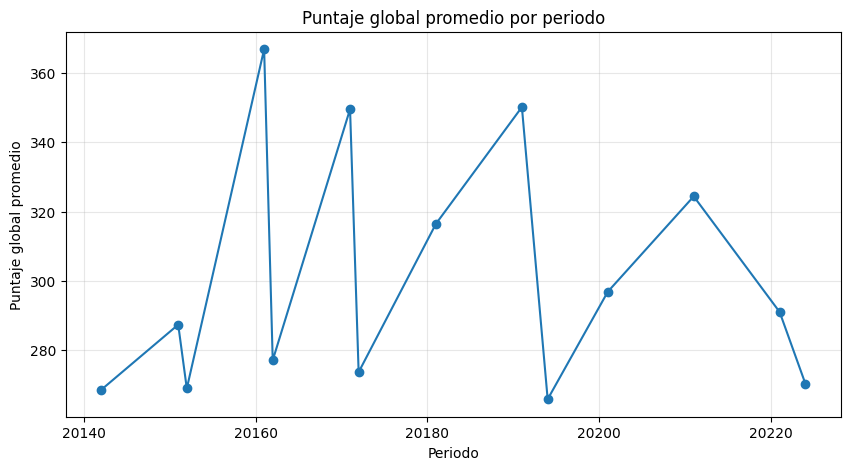

In [9]:
# Gráfico simple con matplotlib: puntaje global promedio por periodo
promedios = df.groupby("periodo")["punt_global"].mean().dropna()

plt.figure(figsize=(10, 5))
plt.plot(promedios.index, promedios.values, marker="o")
plt.title("Puntaje global promedio por periodo")
plt.xlabel("Periodo")
plt.ylabel("Puntaje global promedio")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Distribución relativa de desempeño en inglés por periodo
if "desemp_ingles" in df.columns:
    distribucion_ingles_periodo = pd.crosstab(
        df["periodo"],
        df["desemp_ingles"],
        normalize="index"
    ).round(3)
    
    display(distribucion_ingles_periodo)

desemp_ingles,a-,a1,a2,b+,b1
periodo,,,,,
20101,0.381,0.185,0.058,0.214,0.162
20102,0.458,0.345,0.098,0.029,0.070
20111,0.401,0.198,0.044,0.179,0.178
20112,0.470,0.379,0.105,0.003,0.042
20121,0.423,0.153,0.044,0.246,0.134
20122,0.396,0.359,0.131,0.017,0.098
20131,0.437,0.159,0.042,0.238,0.124
20132,0.401,0.371,0.115,0.031,0.081
20141,0.355,0.159,0.038,0.243,0.205


## 9. Definición de ventana temporal

Por defecto se propone trabajar con una ventana reciente, por ejemplo **2018, 2019 y 2022**.

La razón es evitar mezclar periodos demasiado antiguos y, al mismo tiempo, reducir el efecto de los años más atípicos de pandemia.

> Esta decisión se puede cambiar, pero debe quedar justificada con las tablas y gráficos anteriores.

In [11]:
# Crear columna de año a partir del periodo
df["anio"] = (
    df["periodo"]
    .astype(str)
    .str[:4]
    .astype(int)
)

# Filtrar ventana temporal recomendada
df = df[
    (df["anio"] >= 2015) &
    (df["anio"] <= 2019)
].copy()

print("Dimensiones después del recorte temporal:", df.shape)

print("\nRegistros por periodo:")
print(df["periodo"].value_counts().sort_index())

print("\nRegistros por año:")
print(df["anio"].value_counts().sort_index())

Dimensiones después del recorte temporal: (456419, 44)

Registros por periodo:
periodo
20151      6792
20152     90046
20161      2596
20162     90058
20171      2530
20172     88542
20181      7491
20191      2446
20194    165918
Name: count, dtype: int64

Registros por año:
anio
2015     96838
2016     92654
2017     91072
2018      7491
2019    168364
Name: count, dtype: int64


## 10. Filtro geográfico

Si el proyecto se enfoca en Bogotá, se filtran los registros asociados a Bogotá.  
Se recomienda usar tanto municipio del colegio como municipio de residencia/presentación para revisar consistencia, pero dejar claro cuál será el criterio principal.

Aquí se usa como criterio principal la ubicación del colegio: `cole_mcpio_ubicacion`.

In [12]:
# Revisar categorías disponibles antes de filtrar
if "cole_mcpio_ubicacion" in df.columns:
    print(df["cole_mcpio_ubicacion"].value_counts(dropna=False).head(30))

cole_mcpio_ubicacion
bogota d.c.    456419
Name: count, dtype: int64


In [13]:
# Filtrar Bogotá usando normalización previa
if "cole_mcpio_ubicacion" in df.columns:
    patrones_bogota = ["bogota", "bogota d.c.", "bogota dc", "bogota, d.c."]
    
    df = df[df["cole_mcpio_ubicacion"].isin(patrones_bogota)].copy()
    
print("Dimensiones después del filtro geográfico:", df.shape)
if "cole_mcpio_ubicacion" in df.columns:
    print(df["cole_mcpio_ubicacion"].value_counts(dropna=False))

Dimensiones después del filtro geográfico: (456419, 44)
cole_mcpio_ubicacion
bogota d.c.    456419
Name: count, dtype: int64


## 11. Revisión de duplicados

Se revisan duplicados por `estu_consecutivo`.  
No se eliminan automáticamente sin revisar, porque podría haber situaciones especiales.

In [14]:
if "estu_consecutivo" in df.columns:
    duplicados = df[df.duplicated(subset=["estu_consecutivo"], keep=False)]
    print("Registros con estu_consecutivo duplicado:", duplicados.shape[0])
    display(duplicados.head())

Registros con estu_consecutivo duplicado: 171750


,periodo,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_codigo_icfes,cole_depto_ubicacion,cole_mcpio_ubicacion,cole_genero,cole_jornada,cole_naturaleza,cole_nombre_establecimiento,cole_nombre_sede,cole_sede_principal,estu_depto_reside,estu_mcpio_reside,estu_depto_presentacion,estu_mcpio_presentacion,estu_estudiante,estu_fechanacimiento,estu_genero,estu_nacionalidad,estu_pais_reside,estu_privado_libertad,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global,anio
164341,20194,sb11201940125751,urbano,no,a,academico,411769000127,411769000127,702142,bogota,bogota d.c.,mixto,unica,no oficial,col nuevo san luis gonzaga,col nuevo san luis gonzaga,si,bogota,bogota d.c.,bogota,bogota d.c.,estudiante,14/11/2002,f,colombia,colombia,no,dos,secundaria (bachillerato) completa,secundaria (bachillerato) incompleta,estrato 2,3 a 4,si,si,si,si,b1,68.0,57.0,62.0,60.0,67.0,310.0,2019
164342,20194,sb11201940049452,urbano,no,a,academico,111279000168,111279000168,073031,bogota,bogota d.c.,mixto,manana,oficial,colegio instituto tecnico internacional (ied),cent educ dist inst tec internacional,si,bogota,bogota d.c.,bogota,bogota d.c.,estudiante,13/02/2000,f,colombia,colombia,no,tres,secundaria (bachillerato) completa,secundaria (bachillerato) incompleta,estrato 2,3 a 4,si,no,no,no,a-,45.0,42.0,40.0,39.0,52.0,217.0,2019
164343,20194,sb11201940049452,urbano,no,a,academico,111279000168,111279000168,073031,bogota,bogota d.c.,mixto,manana,oficial,colegio instituto tecnico internacional (ied),cent educ dist inst tec internacional,si,bogota,bogota d.c.,bogota,bogota d.c.,estudiante,13/02/2000,f,colombia,colombia,no,tres,secundaria (bachillerato) completa,secundaria (bachillerato) incompleta,estrato 2,3 a 4,si,no,no,no,a-,45.0,42.0,40.0,39.0,52.0,217.0,2019
164344,20194,sb11201940292128,urbano,no,a,academico,111279000966,111279000966,025163,bogota,bogota d.c.,mixto,manana,oficial,colegio integrado de fontibon ibep (ied),col dept integrado fontibon,si,bogota,bogota d.c.,bogota,bogota d.c.,estudiante,16/10/2001,m,colombia,colombia,no,dos,secundaria (bachillerato) completa,secundaria (bachillerato) incompleta,estrato 3,5 a 6,no,si,si,si,a1,48.0,50.0,52.0,52.0,56.0,261.0,2019
164345,20194,sb11201940292128,urbano,no,a,academico,111279000966,111279000966,025163,bogota,bogota d.c.,mixto,manana,oficial,colegio integrado de fontibon ibep (ied),col dept integrado fontibon,si,bogota,bogota d.c.,bogota,bogota d.c.,estudiante,16/10/2001,m,colombia,colombia,no,dos,secundaria (bachillerato) completa,secundaria (bachillerato) incompleta,estrato 3,5 a 6,no,si,si,si,a1,48.0,50.0,52.0,52.0,56.0,261.0,2019


In [15]:
# Se decide eliminar duplicados exactos:
antes = df.shape[0]
df = df.drop_duplicates()
despues = df.shape[0]

print(f"Duplicados exactos eliminados: {antes - despues}")
print("Dimensiones:", df.shape)

Duplicados exactos eliminados: 86002
Dimensiones: (370417, 44)


## 12. Revisión de valores faltantes

La limpieza grupal NO debe eliminar masivamente filas con faltantes.  
Primero se documenta el porcentaje de faltantes para que cada integrante decida cómo tratarlos en su modelo.

In [16]:
missing = (
    df.isna().mean()
    .sort_values(ascending=False)
    .to_frame("porcentaje_faltante")
)

missing["porcentaje_faltante"] = (missing["porcentaje_faltante"] * 100).round(2)
missing.head(30)

,porcentaje_faltante
cole_bilingue,14.77
cole_caracter,2.08
fami_tieneinternet,1.90
fami_estratovivienda,1.88
fami_educacionpadre,1.85
fami_educacionmadre,1.83
fami_personashogar,0.95
fami_tieneautomovil,0.87
fami_cuartoshogar,0.84
fami_tienecomputador,0.78


In [17]:
columnas_criticas = [
    "punt_global",
    "cole_bilingue",
    "fami_estratovivienda",
    "fami_educacionpadre",
    "fami_educacionmadre",
    "fami_tieneinternet",
    "fami_personashogar",
    "fami_cuartoshogar",
    "fami_tienecomputador"
]

df = df.dropna(subset=columnas_criticas).copy()

print("Dimensiones después de eliminar faltantes:", df.shape)

Dimensiones después de eliminar faltantes: (306866, 44)


## 13. Limpieza de valores imposibles en puntajes

Los puntajes de Saber 11 deben estar en rangos razonables.  
Aquí se marcan como `NaN` los puntajes fuera de rango, en lugar de eliminar filas inmediatamente.

In [18]:
columnas_puntajes = [
    "punt_ingles",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
    "punt_c_naturales",
    "punt_lectura_critica",
    "punt_global"
]

for col in columnas_puntajes:
    if col in df.columns:
        if col == "punt_global":
            condicion_valida = df[col].between(0, 500)
        else:
            condicion_valida = df[col].between(0, 100)
        
        invalidos = (~condicion_valida) & df[col].notna()
        print(col, "valores inválidos:", invalidos.sum())
        df.loc[invalidos, col] = np.nan

df[columnas_puntajes].describe()

punt_ingles valores inválidos: 0
punt_matematicas valores inválidos: 0
punt_sociales_ciudadanas valores inválidos: 0
punt_c_naturales valores inválidos: 0
punt_lectura_critica valores inválidos: 0
punt_global valores inválidos: 0


,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
count,306866.000000,306866.000000,306866.000000,306866.000000,306866.000000,306866.000000
mean,56.533813,55.565276,54.134808,55.182454,55.809422,276.388662
std,13.578128,12.024311,11.424057,10.149351,9.715731,49.505912
min,0.000000,0.000000,0.000000,0.000000,0.000000,51.000000
25%,46.000000,47.000000,46.000000,48.000000,49.000000,241.000000
50%,54.000000,55.000000,54.000000,55.000000,56.000000,274.000000
75%,65.000000,63.000000,62.000000,62.000000,63.000000,310.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,494.000000


## 14. Conversión prudente de variables del hogar

Algunas variables como personas por hogar o cuartos del hogar pueden venir como texto/categorías.  
Primero revisamos sus valores únicos antes de convertirlas.

In [19]:
for col in ["fami_personashogar", "fami_cuartoshogar", "fami_estratovivienda"]:
    if col in df.columns:
        print("", col)
        print(df[col].value_counts(dropna=False).head(30))

 fami_personashogar
fami_personashogar
3 a 4         76749
cuatro        56397
5 a 6         41820
cinco         35902
tres          31970
seis          14344
1 a 2         11588
dos           10539
7 a 8          8939
siete          6003
9 o mas        4414
ocho           3117
nueve          1416
doce o mas     1232
diez           1069
una             827
once            540
Name: count, dtype: int64
 fami_cuartoshogar
fami_cuartoshogar
tres          135044
dos            97457
cuatro         41962
cinco          12923
uno            10073
seis o mas      4764
seis            2405
siete           1009
ocho             608
diez o mas       403
nueve            218
Name: count, dtype: int64
 fami_estratovivienda
fami_estratovivienda
estrato 2      130240
estrato 3      106550
estrato 1       30628
estrato 4       24005
estrato 5        8440
estrato 6        6155
sin estrato       848
Name: count, dtype: int64


In [20]:
def convertir_personas_hogar(valor):
    if pd.isna(valor):
        return pd.NA
    
    valor = str(valor).strip().lower()
    
    mapa = {
        "una": 1,
        "dos": 2,
        "tres": 3,
        "cuatro": 4,
        "cinco": 5,
        "seis": 6,
        "siete": 7,
        "ocho": 8,
        "nueve": 9,
        "diez": 10,
        "once": 11,
        "3 a 4": 3.5,
        "5 a 6": 5.5,
        "1 a 2": 1.5,
        "7 a 8": 7.5,
        "9 o mas": 9,
        "doce o mas": 12
    }
    
    return mapa.get(valor, pd.NA)


def convertir_cuartos_hogar(valor):
    if pd.isna(valor):
        return pd.NA
    
    valor = str(valor).strip().lower()
    
    mapa = {
        "uno": 1,
        "dos": 2,
        "tres": 3,
        "cuatro": 4,
        "cinco": 5,
        "seis": 6,
        "siete": 7,
        "ocho": 8,
        "nueve": 9,
        "seis o mas": 6,
        "diez o mas": 10
    }
    
    return mapa.get(valor, pd.NA)


def convertir_estrato(valor):
    if pd.isna(valor):
        return pd.NA
    
    valor = str(valor).strip().lower()
    
    mapa = {
        "estrato 1": 1,
        "estrato 2": 2,
        "estrato 3": 3,
        "estrato 4": 4,
        "estrato 5": 5,
        "estrato 6": 6
    }
    
    return mapa.get(valor, pd.NA)

In [21]:
df["fami_personashogar_num"] = df["fami_personashogar"].apply(convertir_personas_hogar)
df["fami_cuartoshogar_num"] = df["fami_cuartoshogar"].apply(convertir_cuartos_hogar)
df["fami_estratovivienda_num"] = df["fami_estratovivienda"].apply(convertir_estrato)

df[[
    "fami_personashogar", "fami_personashogar_num",
    "fami_cuartoshogar", "fami_cuartoshogar_num",
    "fami_estratovivienda", "fami_estratovivienda_num"
]].head()

,fami_personashogar,fami_personashogar_num,fami_cuartoshogar,fami_cuartoshogar_num,fami_estratovivienda,fami_estratovivienda_num
164341,3 a 4,3.5,dos,2,estrato 2,2
164342,3 a 4,3.5,tres,3,estrato 2,2
164344,5 a 6,5.5,dos,2,estrato 3,3
164348,7 a 8,7.5,seis o mas,6,estrato 2,2
164350,1 a 2,1.5,uno,1,estrato 3,3


In [22]:
df[[
    "fami_personashogar_num",
    "fami_cuartoshogar_num",
    "fami_estratovivienda_num"
]].isna().mean().sort_values() * 100

fami_personashogar_num      0.000000
fami_cuartoshogar_num       0.000000
fami_estratovivienda_num    0.276342
dtype: float64

Eliminamos los datos de sin estrato que se encuentran en la base

In [23]:
df = df.dropna(
    subset=["fami_estratovivienda_num"]
).copy()

## 15. Edad del estudiante

Se calcula edad aproximada a partir de la fecha de nacimiento y el periodo.  
Luego se marcan como faltantes edades poco plausibles.

In [24]:
if "estu_fechanacimiento" in df.columns:
    
    # Intento 1: formato día/mes/año
    df["estu_fechanacimiento_dt"] = pd.to_datetime(
        df["estu_fechanacimiento"],
        errors="coerce",
        dayfirst=True
    )

    # Crear año desde periodo
    df["anio"] = df["periodo"].astype(str).str[:4].astype(int)

    # Fecha de referencia: 1 de enero del año del periodo
    fecha_referencia = pd.to_datetime(
        df["anio"].astype(str) + "-01-01",
        errors="coerce"
    )

    # Edad aproximada
    df["edad"] = (
        (fecha_referencia - df["estu_fechanacimiento_dt"]).dt.days / 365
    ).round(1)

    # Marcar edades poco plausibles como NaN
    edades_invalidas = (~df["edad"].between(15, 40)) & df["edad"].notna()

    print("Edades inválidas detectadas:", edades_invalidas.sum())

    df.loc[edades_invalidas, "edad"] = pd.NA

    display(df["edad"].describe())

Edades inválidas detectadas: 4268


count    301723.000000
mean         17.036446
std           2.090298
min          15.000000
25%          16.100000
50%          16.600000
75%          17.400000
max          40.000000
Name: edad, dtype: float64

In [25]:
df = df.dropna(subset=["edad"]).copy()
print("Dimensiones después de limpiar edad:", df.shape)

Dimensiones después de limpiar edad: (301723, 49)


## 16. Features base opcionales, no definitivas

Estas variables pueden quedar en el dataset limpio porque son interpretables y útiles para varios modelos.  
Cada integrante decide después si las usa o no.

In [26]:
# Densidad del hogar: personas / cuartos
if {"fami_personashogar_num", "fami_cuartoshogar_num"}.issubset(df.columns):
    df["densidad_hogar"] = df["fami_personashogar_num"] / df["fami_cuartoshogar_num"]
    df.loc[~np.isfinite(df["densidad_hogar"]), "densidad_hogar"] = np.nan
    df.loc[df["densidad_hogar"] > 20, "densidad_hogar"] = np.nan

# Índice tecnológico simple: internet + computador
if {"fami_tieneinternet", "fami_tienecomputador"}.issubset(df.columns):
    df["indice_tecnologico"] = (
        (df["fami_tieneinternet"] == "si").astype(int) +
        (df["fami_tienecomputador"] == "si").astype(int)
    )

# Índice básico de bienes del hogar
bienes = ["fami_tieneinternet", "fami_tienecomputador", "fami_tieneautomovil", "fami_tienelavadora"]
bienes_existentes = [c for c in bienes if c in df.columns]

if bienes_existentes:
    df["indice_bienes_hogar"] = sum((df[c] == "si").astype(int) for c in bienes_existentes)

features_creadas = [c for c in ["densidad_hogar", "indice_tecnologico", "indice_bienes_hogar"] if c in df.columns]
df[features_creadas].describe()

,densidad_hogar,indice_tecnologico,indice_bienes_hogar
count,301723.000000,301723.000000,301723.000000
mean,1.574980,1.704212,2.977503
std,0.630466,0.622407,1.030284
min,0.100000,0.000000,0.000000
25%,1.166667,2.000000,3.000000
50%,1.500000,2.000000,3.000000
75%,1.833333,2.000000,4.000000
max,12.000000,2.000000,4.000000


## 17. Revisión de categorías finales

Esta revisión permite detectar categorías raras o inconsistentes antes de exportar el dataset limpio.

In [27]:
columnas_categoricas_clave = [
    "cole_area_ubicacion",
    "cole_bilingue",
    "cole_calendario",
    "cole_caracter",
    "cole_genero",
    "cole_jornada",
    "cole_naturaleza",
    "estu_genero",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_estratovivienda",
    "desemp_ingles"
]

for col in columnas_categoricas_clave:
    if col in df.columns:
        print("" + "="*80)
        print(col)
        print(df[col].value_counts(dropna=False).head(30))

cole_area_ubicacion
cole_area_ubicacion
urbano    299073
rural       2650
Name: count, dtype: int64
cole_bilingue
cole_bilingue
no    292024
si      9699
Name: count, dtype: int64
cole_calendario
cole_calendario
a       287397
b        11627
otro      2699
Name: count, dtype: int64
cole_caracter
cole_caracter
academico            260047
tecnico/academico     35809
tecnico                4897
NaN                     634
no aplica               336
Name: count, dtype: int64
cole_genero
cole_genero
mixto        275978
femenino      16835
masculino      8910
Name: count, dtype: int64
cole_jornada
cole_jornada
completa    122882
manana       93485
tarde        51910
noche        17574
unica         9604
sabatina      6268
Name: count, dtype: int64
cole_naturaleza
cole_naturaleza
oficial       154427
no oficial    147296
Name: count, dtype: int64
estu_genero
estu_genero
f      160172
m      141405
NaN       146
Name: count, dtype: int64
fami_educacionmadre
fami_educacionmadre
secundaria (bac

## 18. Revisión específica de variables objetivo potenciales

Aunque este notebook no crea targets definitivos, sí revisa las variables que probablemente se usarán para las preguntas:

- Regresión: `punt_global`.
- Clasificación binaria: derivada de `punt_global`.
- Clasificación multiclase: `desemp_ingles`.

In [28]:
if "punt_global" in df.columns:
    print("Resumen punt_global")
    display(df["punt_global"].describe())
    
    p25 = df["punt_global"].quantile(0.25)
    p75 = df["punt_global"].quantile(0.75)
    print("Percentil 25:", round(p25, 2))
    print("Percentil 75:", round(p75, 2))

if "desemp_ingles" in df.columns:
    print("Distribución desempeño inglés")
    display((df["desemp_ingles"].value_counts(normalize=True) * 100).round(2))

Resumen punt_global


count    301723.000000
mean        276.875266
std          49.253747
min          73.000000
25%         242.000000
50%         275.000000
75%         310.000000
max         494.000000
Name: punt_global, dtype: float64

Percentil 25: 242.0
Percentil 75: 310.0
Distribución desempeño inglés


desemp_ingles
a1    32.63
a-    27.40
a2    19.90
b1    13.61
b+     6.46
Name: proportion, dtype: float64

## 19. Data leakage: advertencia metodológica

Para los modelos que predigan `punt_global`, no se recomienda usar como predictoras:

- `punt_ingles`
- `punt_matematicas`
- `punt_sociales_ciudadanas`
- `punt_c_naturales`
- `punt_lectura_critica`

porque el puntaje global se construye a partir de esas pruebas. Usarlas generaría fuga de información.

Estas columnas pueden mantenerse en el dataset limpio, pero cada integrante debe decidir si excluirlas del conjunto de variables predictoras según su modelo.

## 20. Resumen final de calidad

In [29]:
print("Dimensiones finales:", df.shape)
print("Periodos finales:")
print(df["periodo"].value_counts().sort_index())

print("Porcentaje de faltantes final:")
missing_final = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
display(missing_final.to_frame("% faltantes").head(40))

print("Tipos de datos finales:")
display(df.dtypes.to_frame("tipo"))

Dimensiones finales: (301723, 52)
Periodos finales:
periodo
20151     5964
20152    76834
20161     2442
20162    75661
20171     2234
20172    69069
20181     3606
20191     2190
20194    63723
Name: count, dtype: int64
Porcentaje de faltantes final:


,% faltantes
cole_caracter,0.21
fami_tieneautomovil,0.10
estu_genero,0.05
fami_tienelavadora,0.03
estu_mcpio_reside,0.01
estu_depto_reside,0.01
periodo,0.00
punt_matematicas,0.00
fami_estratovivienda,0.00
fami_personashogar,0.00


Tipos de datos finales:


,tipo
periodo,int64
estu_consecutivo,object
cole_area_ubicacion,object
cole_bilingue,object
cole_calendario,object
cole_caracter,object
cole_cod_dane_establecimiento,object
cole_cod_dane_sede,object
cole_codigo_icfes,object
cole_depto_ubicacion,object


## 21. Quitar la secuencia para dejarlo limpio para que quede bien

Se debe quitar la secuencia y unas columnas que ya no aportan

In [31]:
df = df.drop(columns=["estu_fechanacimiento_dt"])
df = df.drop(columns=["estu_consecutivo"])

## 22. Exportar dataset limpio

Se exporta un archivo limpio base para que cada integrante haga su análisis/modelamiento específico.

In [32]:
RUTA_SALIDA = Path("/Users/anamariasanchezmejia/Desktop/Proyecto2_saber11/Notebooks/saber11_limpio_base.csv")
RUTA_SALIDA.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(RUTA_SALIDA, index=False, encoding="utf-8-sig")

print("Archivo exportado en:", RUTA_SALIDA)
print("Dimensiones exportadas:", df.shape)

Archivo exportado en: /Users/anamariasanchezmejia/Desktop/Proyecto2_saber11/Notebooks/saber11_limpio_base.csv
Dimensiones exportadas: (301723, 50)
